In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt


# OBTENCION DE RESULTADOS

In [13]:
pathresults=r"C:\Users\Gabo\Desktop\PAPPER Rlaif\getResultados\evaluatedResponses\evaluatedResponses"
archivos=os.listdir(pathresults)
prompts=pd.read_csv(r"C:\Users\Gabo\Desktop\PAPPER Rlaif\makeResponses\promptBases\finalPromptBases\elementary_math_prompts_1200.csv")
print(archivos)

['evaluated_math_elementary_responses_deepSeek.csv', 'evaluated_math_elementary_responses_gpt.csv', 'evaluated_responses_DPO_DeepSeek-R1-Distill-Qwen-1.5B_lora_dpo.csv', 'evaluated_responses_DPO_Llama-3.2-1B-Instruct_lora_dpo.csv', 'evaluated_responses_DPO_Qwen2.5-1.5B-Instruct_lora_dpo.csv', 'evaluated_responses_PPO_DeepSeek-R1-Distill-Qwen-1.5B-PPO.csv', 'evaluated_responses_PPO_Llama-3.2-1B-Instruct-PPO.csv', 'evaluated_responses_PPO_Qwen2.5-1.5B-Instruct-PPO.csv', 'evaluated_resultDeepSeek-R1-Distill-Qwen-1.5B_1.csv', 'evaluated_resultLlama-3.2-1B-Instruct_1.csv', 'evaluated_resultQwen2.5-1.5B-Instruct_1.csv']


In [14]:
prompts.columns

Index(['skill', 'prompt', 'id_prompt'], dtype='object')

In [20]:
a=pd.read_csv(pathresults+"\\"+archivos[6])
a.rename(columns={'Unnamed: 0':'id_prompt'}, inplace=True)
b=pd.merge(a,prompts,on='id_prompt')
print(a.shape)
print(b.shape)
print(b.isna().sum().sum())

(200, 32)
(200, 34)
0


In [24]:
b[['response','prompt']].values[0]

array(["Here's a two-step problem that connects flowers to geometry:\n\n**Problem:**\n\nA flower has 5 petals. Each petal is a triangle. If the flower is a daisy, what is the sum of the interior angles of the daisy petals?\n\n**Solution:**\n\nTo solve this problem, we need to recall that the sum of the interior angles of a triangle is always 180 degrees. Since there are 5 petals, we can divide 180 degrees by 5 to find the sum of the interior angles of the daisy petals.\n\n180 degrees ÷ 5 = 36 degrees\n\nSo, the sum of the interior angles of the daisy petals is 36 degrees.\n\n**Answer:** 36 degrees",
       'Write a multiple-choice question with four options where students first add and then subtract using cookies. Make it easy. Ask for a written answer, not a drawing.'],
      dtype=object)

In [9]:
a.columns

Index(['Unnamed: 0', 'response', 'predicted_index_claridad',
       'predicted_label_claridad', 'confidence_claridad',
       'probability_class_0_claridad', 'probability_class_1_claridad',
       'prob_0_claridad', 'prob_1_claridad', 'predicted_index_subject',
       'predicted_label_subject', 'confidence_subject',
       'probability_class_0_subject', 'probability_class_1_subject',
       'prob_mathematics_subject', 'prob_otro_subject',
       'predicted_index_skill', 'predicted_label_skill', 'confidence_skill',
       'prob_addition-subtraction_skill', 'prob_algebra_skill',
       'prob_division-multiplication_skill', 'prob_geometry_skill',
       'prob_otro_skill', 'prob_subtraction_skill', 'predicted_index_level',
       'predicted_label_level', 'confidence_level',
       'probability_class_0_level', 'probability_class_1_level',
       'prob_ELEMENTARY_level', 'prob_OTRO_level'],
      dtype='object')

In [17]:
prompts.head()

,skill,prompt,id_prompt
0,addition-subtraction,Write a multiple-choice question with four opt...,0
1,addition-subtraction,Generate a multiple-choice question with four ...,1
2,addition-subtraction,Generate a two-step problem about comparing an...,2
3,addition-subtraction,Create a fill-in-the-blank question that asks ...,3
4,addition-subtraction,Write a simple challenge question where studen...,4


In [39]:
columns=['response', 
         'predicted_index_claridad','predicted_label_claridad',
         'predicted_index_subject', 'predicted_label_subject',
         'predicted_index_skill', 'predicted_label_skill',
         'predicted_index_level', 'predicted_label_level']
labels=[x for x in columns if 'predicted_label_' in x] 

basesresult={}
claves={'claridad':1,
        'level':"ELEMENTARY",
        'subject':"mathematics",}

for i in range(len(archivos)):
    db=pd.read_csv(pathresults+"\\"+archivos[i], index_col=0)
    db1=db[columns].copy()
    if not 'prompt' in db1.columns or not 'skill' in db1.columns:
        print(archivos[i])
    else:
        print(archivos[i], "PROMT SKILL")
    
    if db1.shape[0]==prompts.shape[0]:
        db1['prompt']=prompts['prompt']
        db1['skill']=prompts['skill']

    model_name=archivos[i].split('.')[0]
    result={}
    for label in labels:
        k=label.split('predicted_label_')[-1]
        r= db1[label].value_counts()
        if k=='skill':
            continue
        print(r.index)
        try:
            porcentaje=r[claves[k]]/db1.shape[0]
        except:
            porcentaje=0
        
        result[k]=porcentaje
    
    basesresult[model_name]=result

    
    
    
    


evaluated_math_elementary_responses_deepSeek.csv
Index([1, 0], dtype='int64', name='predicted_label_claridad')
Index(['mathematics', 'otro'], dtype='object', name='predicted_label_subject')
Index(['ELEMENTARY', 'OTRO'], dtype='object', name='predicted_label_level')
evaluated_math_elementary_responses_gpt.csv
Index([1, 0], dtype='int64', name='predicted_label_claridad')
Index(['otro', 'mathematics'], dtype='object', name='predicted_label_subject')
Index(['ELEMENTARY', 'OTRO'], dtype='object', name='predicted_label_level')
evaluated_responses_DPO_DeepSeek-R1-Distill-Qwen-1.5B_lora_dpo.csv
Index([0, 1], dtype='int64', name='predicted_label_claridad')
Index(['otro'], dtype='object', name='predicted_label_subject')
Index(['ELEMENTARY'], dtype='object', name='predicted_label_level')
evaluated_responses_DPO_Llama-3.2-1B-Instruct_lora_dpo.csv
Index([1, 0], dtype='int64', name='predicted_label_claridad')
Index(['mathematics', 'otro'], dtype='object', name='predicted_label_subject')
Index(['ELEM

evaluated_math_elementary_responses_deepSeek
evaluated_math_elementary_responses_gpt
evaluated_responses_DPO_DeepSeek-R1-Distill-Qwen-1
evaluated_responses_DPO_Llama-3
evaluated_responses_DPO_Qwen2
evaluated_responses_PPO_DeepSeek-R1-Distill-Qwen-1
evaluated_responses_PPO_Llama-3
evaluated_responses_PPO_Qwen2
evaluated_resultDeepSeek-R1-Distill-Qwen-1
evaluated_resultLlama-3
evaluated_resultQwen2


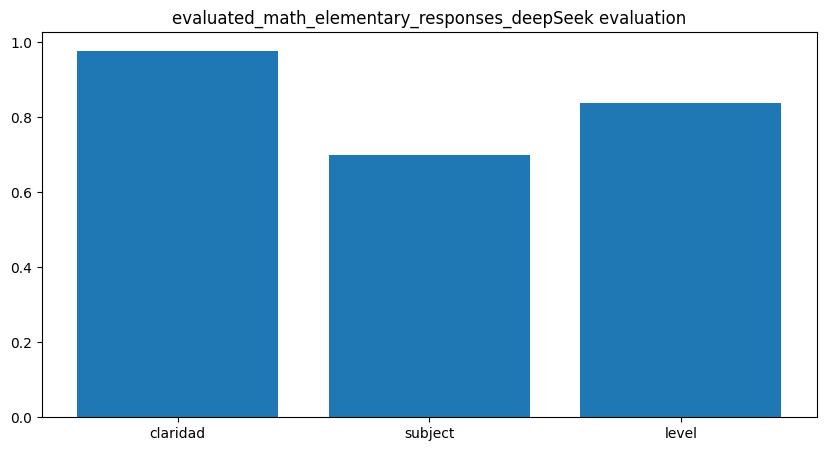

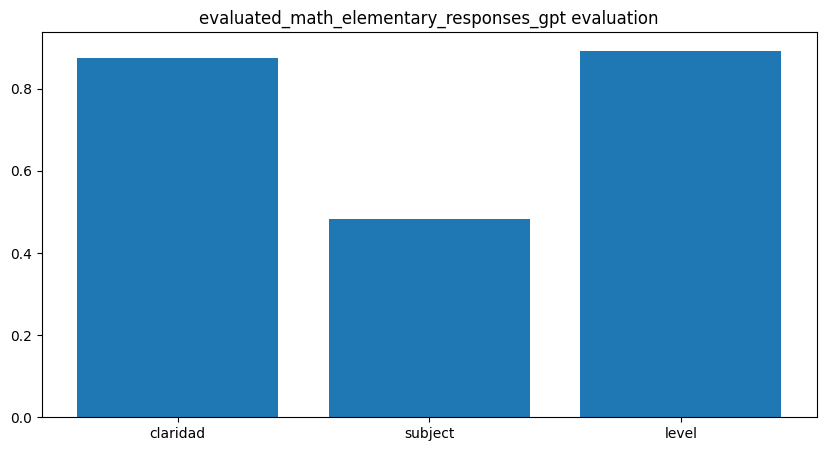

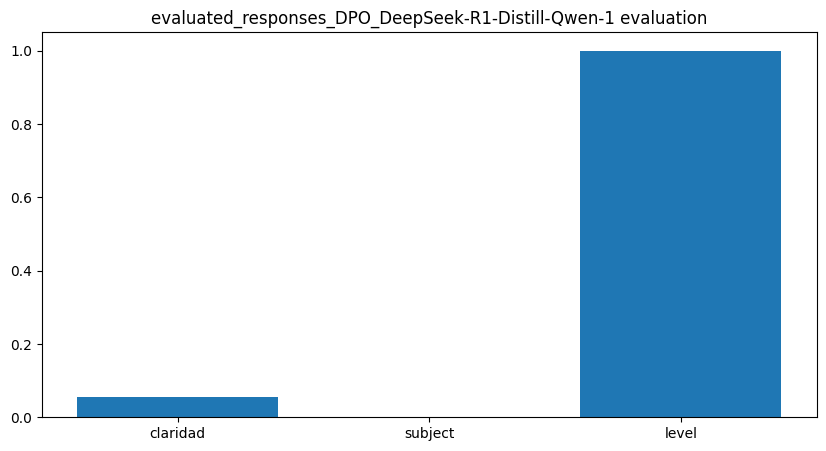

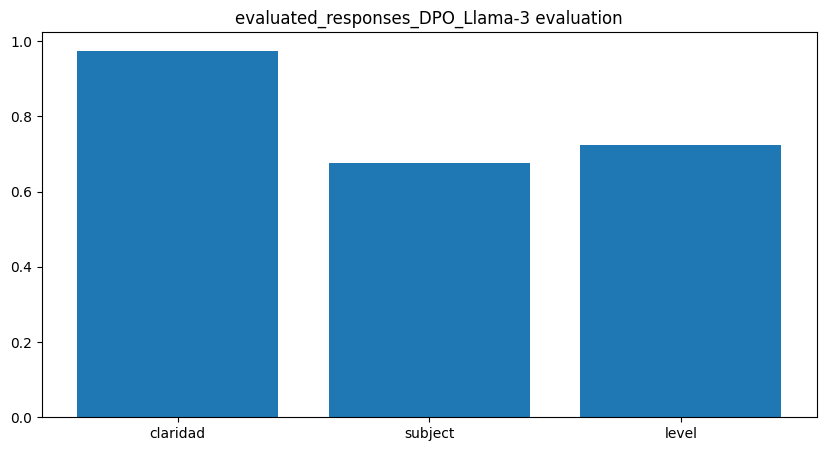

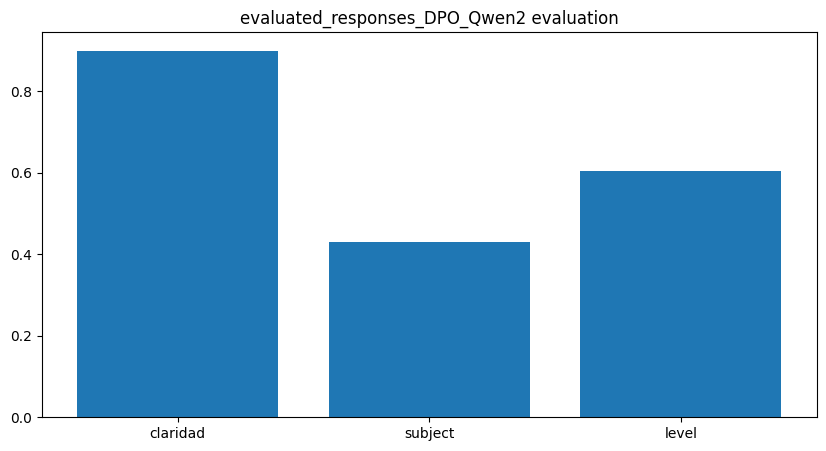

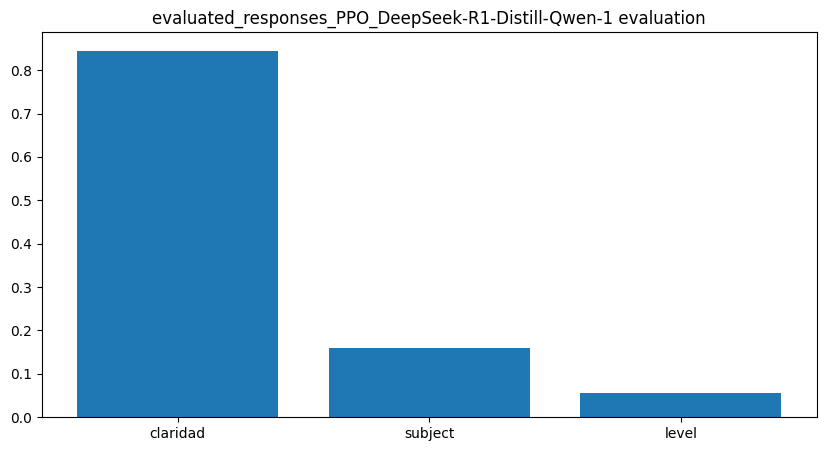

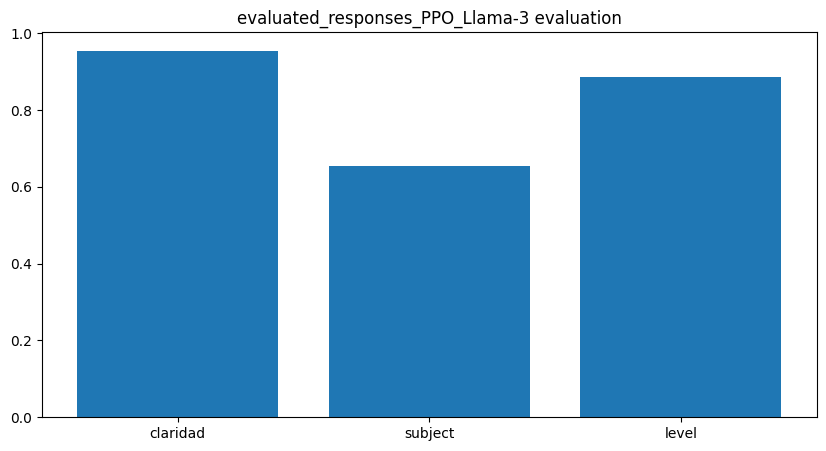

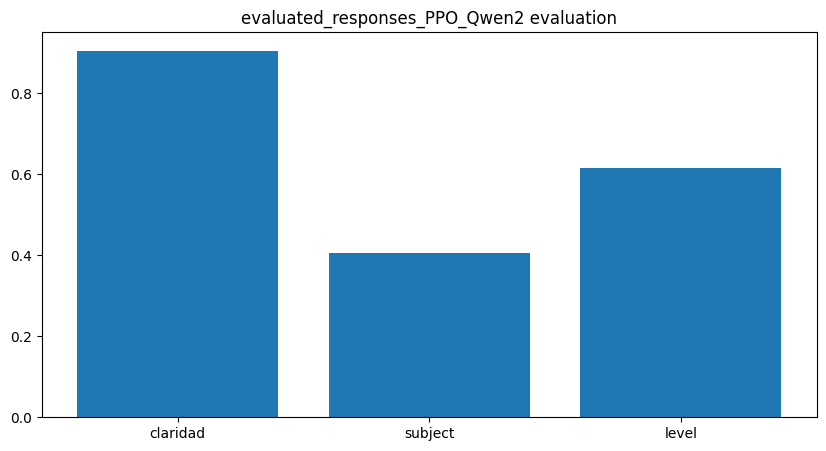

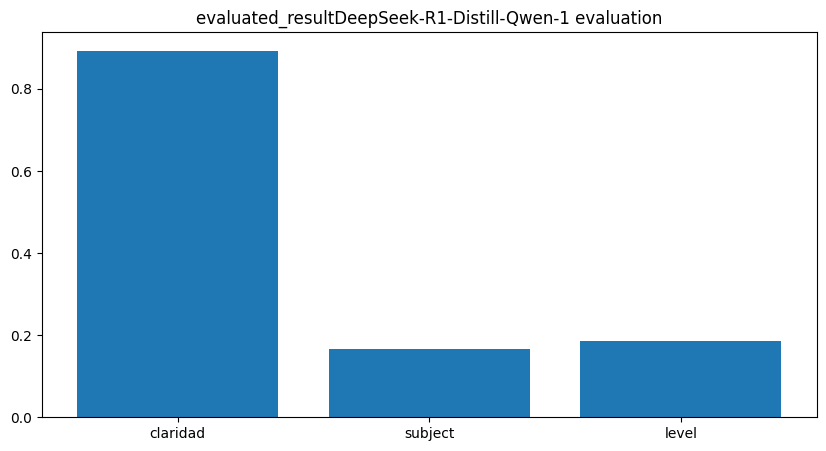

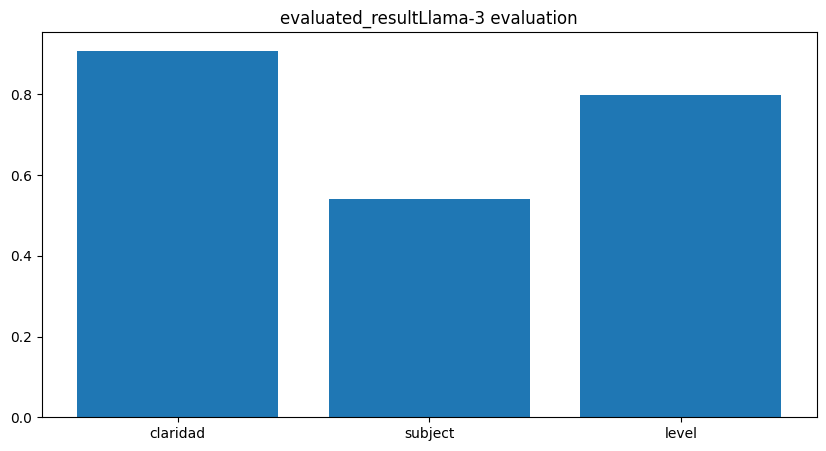

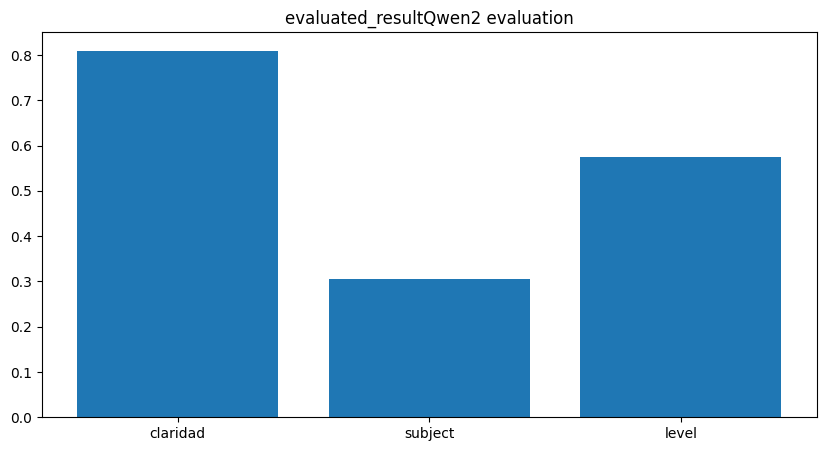

In [ ]:
for k in basesresult.keys():
    print(k)
    plt.figure(figsize=(10,5))
    plt.bar(basesresult[k].keys(), basesresult[k].values())
    plt.title(f"{k} evaluation")

evaluated_math_elementary_responses_deepSeek 0.9780487804878049


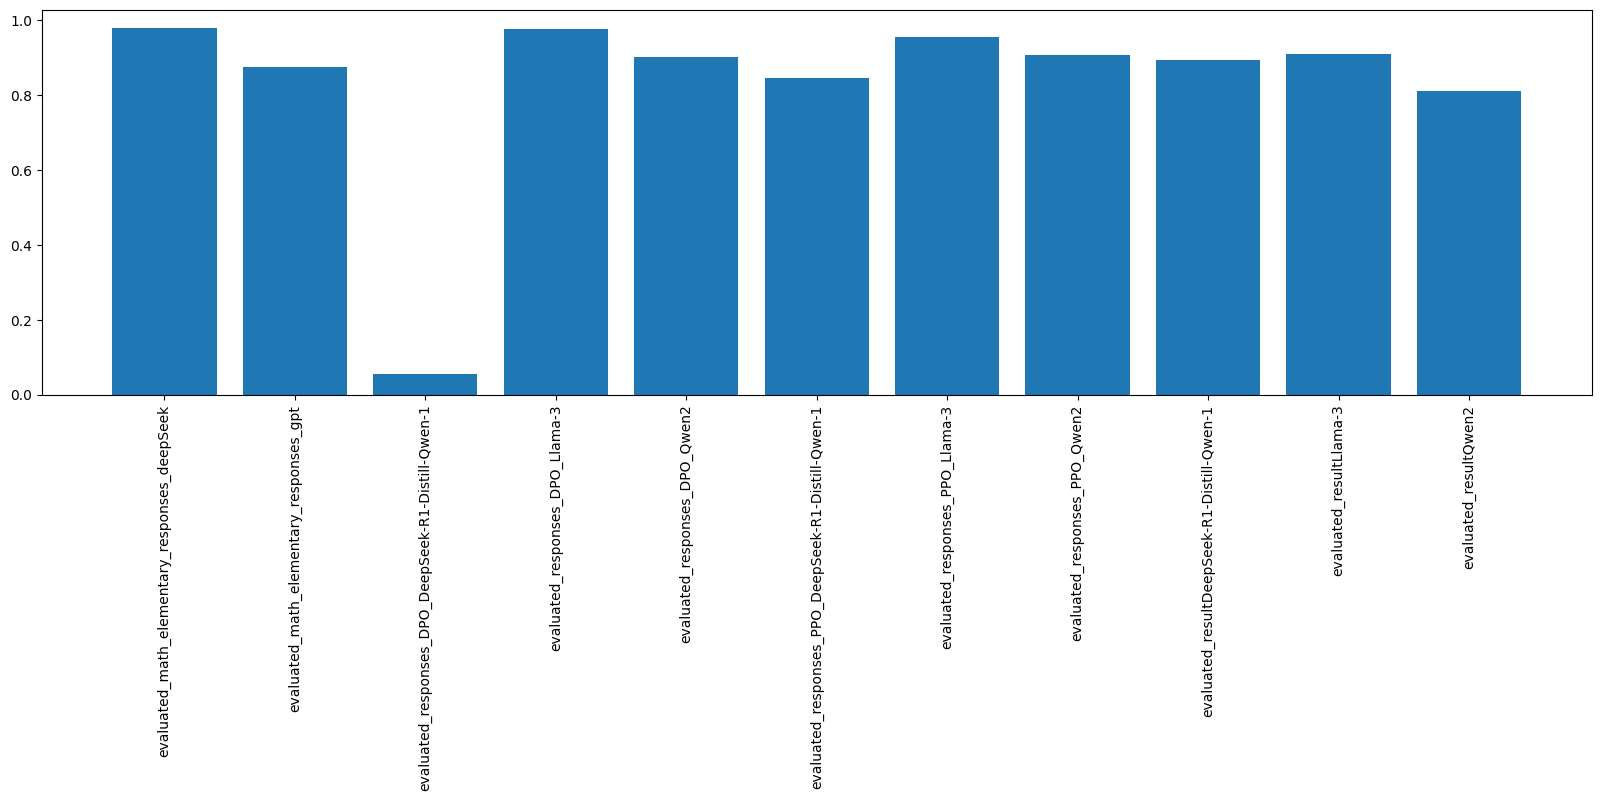

In [51]:
models=list(basesresult.keys())
results=pd.DataFrame(basesresult)
y=[]
for v in basesresult.values():
    y.append(list(v.values())[0])
plt.figure(figsize=(20,5))
plt.bar(models, y)
plt.xticks(rotation=90)
print(models[y.index(max(y))],max(y))

In [68]:
final_results =results.T
final_results['mean_accuracy']=final_results.mean(axis=1)
final_results['selection_score']=(final_results['claridad']*0.5+final_results['level']*0.2+final_results['subject']*0.3)*100

In [64]:
type(final_results)

pandas.core.frame.DataFrame

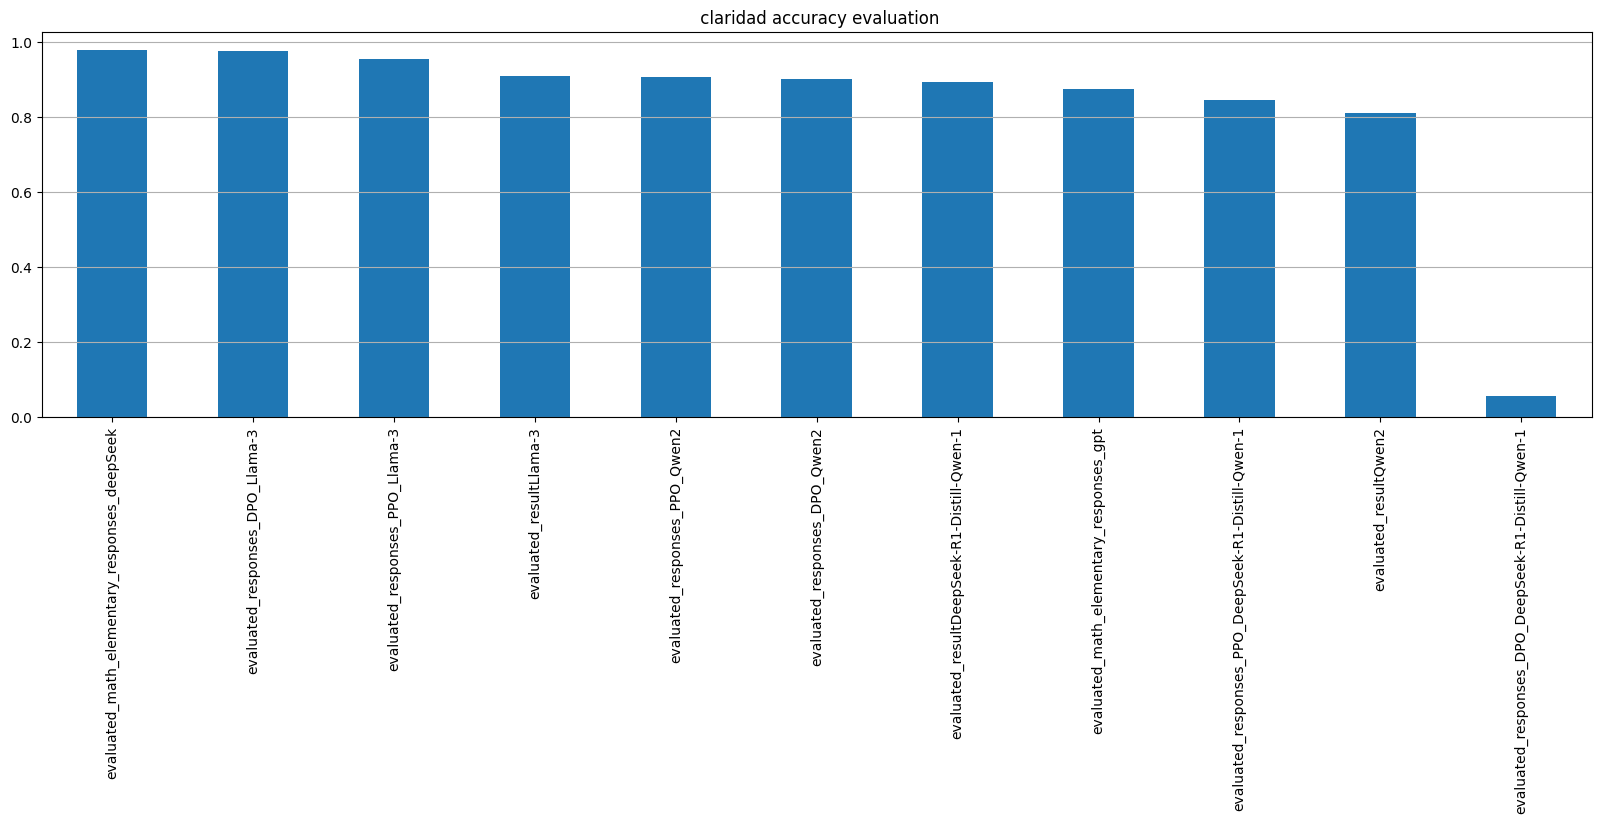

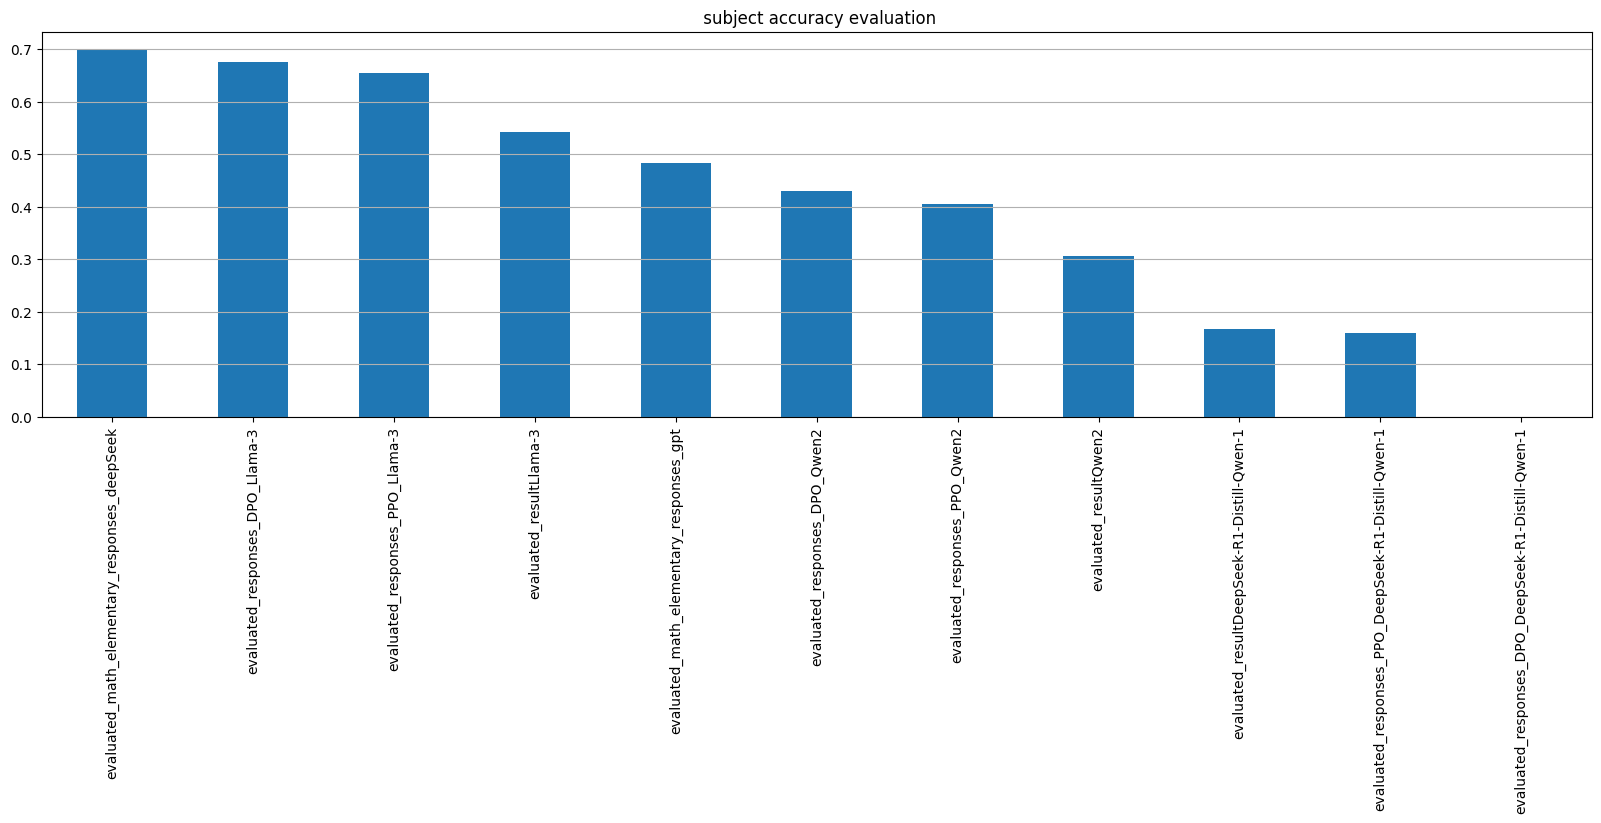

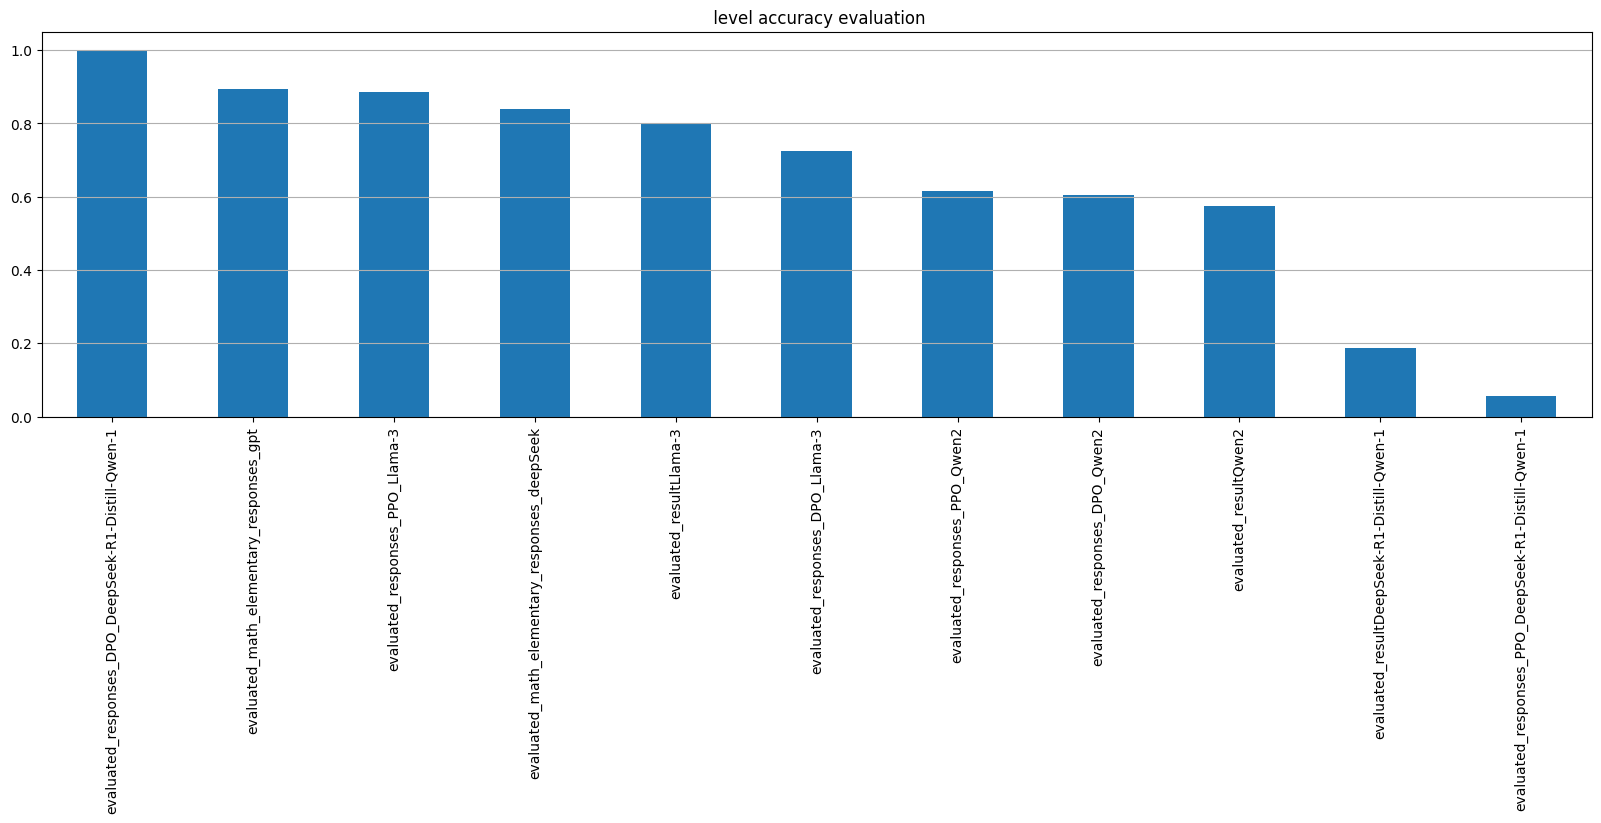

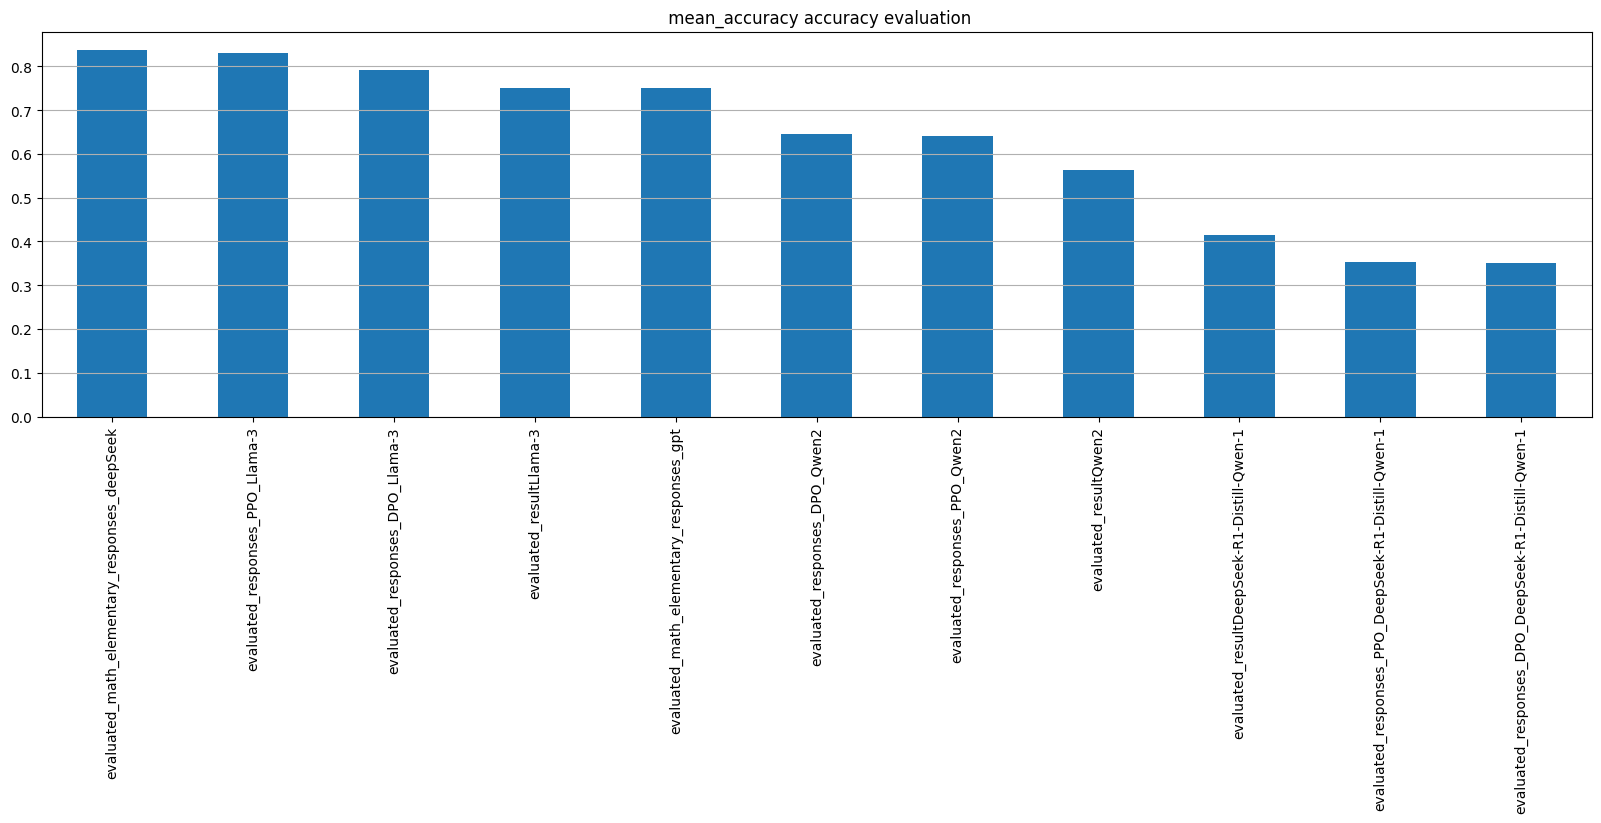

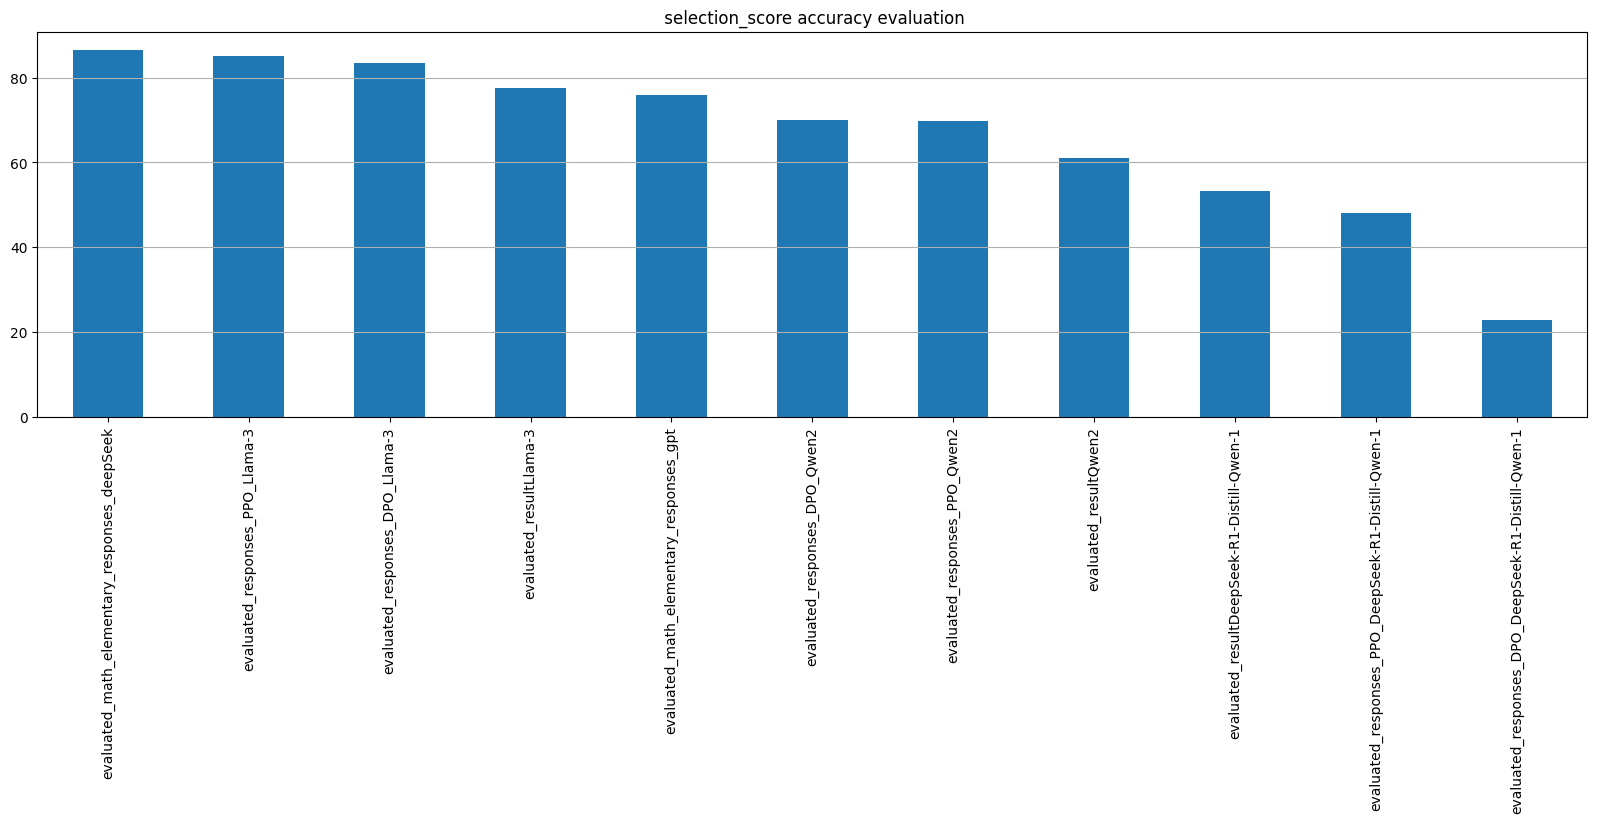

In [72]:
for c  in  final_results.columns:
    rr=final_results[c].sort_values(ascending=False)
    plt.figure()
    rr.plot(kind='bar', figsize=(20,5))
    plt.grid(axis='y')
    plt.title(f" {c} accuracy evaluation")